# StreamView Analytics — Evaluación Parcial N°1
## Visualización de Datos (ADY1104)

**Caso de estudio:** StreamView Analytics — plataforma ficticia de streaming digital

**Integrantes:** [Matias Arauz] · [Michelangelo Bandelli] · [Sebastian Gonzalez Pino] · [Hernan Lippke]

**Docente:** [Pablo Espinoza]

**Fecha:** [19-09-2026]

**Período de análisis:** 01-01-2025 al 31-12-2025

---

## Tabla de contenidos

[Definición del problema de negocio](#1)

[Audiencia objetivo y propósito comunicacional](#2)

[Fuentes de datos y metodología](#3)

Análisis exploratorio y hallazgos por integrante
   - Retención y cancelación de clientes — 🔲 *Pendiente* — Responsable: **[Integrante 1]**
   - Reproducciones, minutos vistos, % completado y abandono — * — Responsable: **[Hernan]**
   - Preferencias de contenido — 🔲 *Pendiente* — Responsable: **[Machine Learning]**
   - Experiencia técnica por dispositivo — 🔲 *Pendiente* — Responsable: **[Integrante 4]**
   - Relación entre consumo, interacciones y calificaciones — * — Responsable: **[Hernan]**

Dashboard ejecutivo y KPIs — 🔲 *Pendiente (grupal)*

Data Storytelling / narrativa visual — 🔲 *Pendiente (grupal)*

Conclusiones y recomendaciones — 🔲 *Pendiente

> **¿Qué queremos analizar? → ¿Por qué elegimos este gráfico? → ¿Qué hallazgo encontramos? → ¿Qué significa para la organización? → ¿Qué decisión o recomendación podemos proponer?**


### Definición del problema de negocio — 🔲 *Pendiente revision (grupal)*

**Preguntas guía para completar en equipo:**
- ¿Qué decisión de negocio queremos apoyar? (retención, upsell de planes, inversión en catálogo, mejora técnica, etc.)
- ¿Por qué es un problema relevante hoy para StreamView Analytics?
- ¿Qué pasaría si no se aborda?

> StreamView Analytics necesita entender qué combinación de contenido, dispositivo y experiencia de uso mantiene a un usuario reproduciendo, interactuando y suscrito, para dirigir mejor sus decisiones de catálogo, producto y retención.


### Audiencia objetivo y propósito comunicacional — 🔲 *Pendiente revision (grupal)*

**Preguntas guía para completar en equipo:**
- ¿Quién va a ver el dashboard/reporte? (ej. Gerencia de Producto, equipo de Retención, Marketing, Dirección General)
- ¿Qué nivel de detalle técnico maneja esa audiencia?
- ¿Qué decisión concreta tomará esa audiencia con lo que le mostremos?
- ¿Qué tono/formato es el adecuado (ejecutivo y de alto nivel vs. analítico y detallado)?

*Sugerencia:* dado que las 5 líneas de análisis del equipo combinan negocio (retención), producto (contenido, consumo) y tecnología (dispositivos), una audiencia natural es un **comité de Producto y Retención**, con un propósito **informativo + persuasivo**: mostrar dónde se pierde/gana engagement y qué acción tomar.

### Fuentes de datos y metodología

Trabajamos con las 7 tablas del dataset StreamView Analytics descritas en el `README.txt` y su diccionario de datos. Las claves de relación son:

- `usuarios.usuario_id` → `suscripciones`, `dispositivos`, `reproducciones`, `calificaciones`, `interacciones`
- `contenidos.contenido_id` → `reproducciones`, `calificaciones`, `interacciones`
- `dispositivos.dispositivo_id` → `reproducciones.dispositivo_id`

### Librerías y carga de datos

In [1]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns

### Configuración visual

In [2]:
sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Paleta de equipo: gris neutro para "el resto" + color de acento para destacar
# el hallazgo relevante en cada gráfico (principio de jerarquía visual / preatención)
COLOR_NEUTRO = "#B0B7C3"
COLOR_ACENTO = "#E4572E"   # naranja: para alertar (ej. peor desempeño)
COLOR_ACENTO_POS = "#2E86AB"  # azul: para destacar en positivo
COLOR_LINEA = "#264653"

In [3]:
from pathlib import Path

# Carpeta de datos: ../data al trabajar desde el repositorio; carpeta actual en Colab
DATA_DIR = Path('../data') if Path('../data').exists() else Path('.')

contenidos = pd.read_csv(DATA_DIR / 'contenidos.csv')
diccionario_datos = pd.read_csv(DATA_DIR / 'diccionario_datos.csv')
dispositivos = pd.read_csv(DATA_DIR / 'dispositivos.csv')
reproducciones = pd.read_csv(DATA_DIR / 'reproducciones.csv')
suscripciones = pd.read_csv(DATA_DIR / 'suscripciones.csv')
usuarios = pd.read_csv(DATA_DIR / 'usuarios.csv')
interacciones = pd.read_csv(DATA_DIR / 'interacciones.csv')
calificaciones = pd.read_csv(DATA_DIR / 'calificaciones.csv')

### Descripción general de las tablas

In [4]:
tablas = {
    'usuarios': usuarios, 'contenidos': contenidos, 'suscripciones': suscripciones,
    'dispositivos': dispositivos, 'reproducciones': reproducciones,
    'calificaciones': calificaciones, 'interacciones': interacciones,
}

for nombre, df in tablas.items():
    print(f"{nombre:15s} -> {df.shape[0]:>6,} filas | {df.shape[1]} columnas")

usuarios        ->  1,500 filas | 8 columnas
contenidos      ->    420 filas | 14 columnas
suscripciones   ->  1,500 filas | 9 columnas
dispositivos    ->  2,492 filas | 6 columnas
reproducciones  -> 25,000 filas | 11 columnas
calificaciones  ->  3,119 filas | 7 columnas
interacciones   ->  7,438 filas | 7 columnas


### Diccionario de datos completo (referencia para todo el equipo):

In [5]:
diccionario_datos

,Tabla,Campo,Tipo,Descripción,Clave/Relación
0,usuarios,usuario_id,Texto,Identificador único del usuario.,PK
1,usuarios,fecha_registro,Fecha,Fecha de alta del usuario en la plataforma.,NaN
2,usuarios,pais,Texto,País de residencia.,NaN
3,usuarios,ciudad,Texto,Ciudad de residencia.,NaN
4,usuarios,edad,Entero,Edad del usuario.,NaN
...,...,...,...,...,...
57,interacciones,contenido_id,Texto,Contenido asociado.,FK -> contenidos.contenido_id
58,interacciones,fecha_hora,FechaHora,Fecha y hora del evento.,NaN
59,interacciones,tipo_interaccion,Texto,Acción realizada.,NaN
60,interacciones,canal,Texto,App o Web.,NaN


In [6]:
archivos = sorted(DATA_DIR.glob('*.csv'))
for archivo in archivos:
    df = pd.read_csv(archivo)
    print(f' Dataframe: {archivo.name} '.center(60, "="))
    df.info()
    display(df.head())
    display(df.describe())

============== Dataframe: calificaciones.csv ===============
<class 'pandas.DataFrame'>
RangeIndex: 3119 entries, 0 to 3118
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   calificacion_id       3119 non-null   str  
 1   usuario_id            3119 non-null   str  
 2   contenido_id          3119 non-null   str  
 3   fecha_calificacion    3119 non-null   str  
 4   puntuacion_1_5        3119 non-null   int64
 5   recomendaria          3119 non-null   str  
 6   categoria_comentario  3119 non-null   str  
dtypes: int64(1), str(6)
memory usage: 324.8 KB


,calificacion_id,usuario_id,contenido_id,fecha_calificacion,puntuacion_1_5,recomendaria,categoria_comentario
0,K00001,U00975,C0363,2025-08-22 08:20:32,4,Sí,Contenido
1,K00002,U00975,C0135,2025-10-26 13:24:35,5,Sí,Historia
2,K00003,U00975,C0324,2025-04-22 20:21:42,4,Sí,Contenido
3,K00004,U00975,C0299,2025-06-07 00:40:30,4,Sí,Experiencia general
4,K00005,U00234,C0008,2025-12-23 20:16:42,4,Sí,Actuación


,puntuacion_1_5
count,3119.000000
mean,3.963450
std,0.539591
min,2.000000
25%,4.000000
50%,4.000000
75%,4.000000
max,5.000000


================ Dataframe: contenidos.csv =================
<class 'pandas.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   contenido_id         420 non-null    str  
 1   titulo               420 non-null    str  
 2   tipo_contenido       420 non-null    str  
 3   genero_principal     420 non-null    str  
 4   subgenero            420 non-null    str  
 5   clasificacion_edad   420 non-null    str  
 6   anio_estreno         420 non-null    int64
 7   duracion_min         420 non-null    int64
 8   temporadas           420 non-null    int64
 9   episodios            420 non-null    int64
 10  idioma_original      420 non-null    str  
 11  pais_origen          420 non-null    str  
 12  exclusivo            420 non-null    str  
 13  fecha_alta_catalogo  420 non-null    str  
dtypes: int64(4), str(10)
memory usage: 79.3 KB


,contenido_id,titulo,tipo_contenido,genero_principal,subgenero,clasificacion_edad,anio_estreno,duracion_min,temporadas,episodios,idioma_original,pais_origen,exclusivo,fecha_alta_catalogo
0,C0001,Marea Alto 1,Serie,Comedia,Romántica,16+,2012,49,1,9,Inglés,Estados Unidos,No,2023-08-19
1,C0002,Tiempo Azul 2,Película,Documental,Sociedad,16+,2001,131,0,1,Español,España,No,2025-07-21
2,C0003,Eco Global 3,Película,Acción,Supervivencia,18+,2005,123,0,1,Inglés,Estados Unidos,Sí,2025-05-09
3,C0004,Destino Rojo 4,Película,Aventura,Exploración,13+,1998,98,0,1,Inglés,España,No,2025-04-08
4,C0005,Eco Norte 5,Documental,Drama,Histórico,13+,2000,73,0,1,Español,España,No,2023-11-24


...

,suscripcion_id,usuario_id,plan,fecha_inicio,fecha_fin,estado,precio_mensual_usd,renovacion_automatica,motivo_cancelacion
0,S00001,U00001,Premium,2024-02-06,NaN,Activa,13.99,Sí,NaN
1,S00002,U00002,Básico,2025-05-13,NaN,Activa,6.99,Sí,NaN
2,S00003,U00003,Básico,2023-03-17,2025-12-20,Cancelada,6.99,No,Precio
3,S00004,U00004,Estándar,2023-01-25,NaN,Activa,9.99,Sí,NaN
4,S00005,U00005,Estándar,2025-03-16,NaN,Activa,9.99,Sí,NaN


,precio_mensual_usd
count,1500.000000
mean,9.658667
std,2.517759
min,6.990000
25%,6.990000
50%,9.990000
75%,9.990000
max,13.990000


================= Dataframe: usuarios.csv ==================
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   usuario_id         1500 non-null   str  
 1   fecha_registro     1500 non-null   str  
 2   pais               1500 non-null   str  
 3   ciudad             1500 non-null   str  
 4   edad               1500 non-null   int64
 5   segmento_edad      1500 non-null   str  
 6   genero             1500 non-null   str  
 7   canal_adquisicion  1500 non-null   str  
dtypes: int64(1), str(7)
memory usage: 178.1 KB


,usuario_id,fecha_registro,pais,ciudad,edad,segmento_edad,genero,canal_adquisicion
0,U00001,2024-02-06,Chile,Concepción,33,25-34,Prefiere no indicar,Orgánico
1,U00002,2025-05-13,Chile,Valparaíso,63,55+,Femenino,Redes sociales
2,U00003,2023-03-17,México,Ciudad de México,32,25-34,Femenino,Referido
3,U00004,2023-01-25,España,Madrid,47,45-54,Femenino,Orgánico
4,U00005,2025-03-16,Chile,La Serena,41,35-44,Femenino,Orgánico


,edad
count,1500.000000
mean,34.393333
std,11.118320
min,18.000000
25%,26.000000
50%,34.000000
75%,42.000000
max,68.000000


### Calidad de datos

Revisamos valores nulos en cada tabla. Es esperable que `suscripciones` tenga nulos en `fecha_fin` y `motivo_cancelacion`: según el README, quedan vacíos cuando la suscripción sigue activa (no es un error de calidad).

In [7]:
for nombre, df in tablas.items():
    nulos = df.isna().sum()
    nulos = nulos[nulos > 0]
    if len(nulos):
        print(f"--- {nombre} ---")
        print(nulos.to_string())
        print()
    else:
        print(f"--- {nombre}: sin valores nulos ---\n")

--- usuarios: sin valores nulos ---

--- contenidos: sin valores nulos ---

--- suscripciones ---
fecha_fin             1085
motivo_cancelacion    1085

--- dispositivos: sin valores nulos ---

--- reproducciones: sin valores nulos ---

--- calificaciones: sin valores nulos ---

--- interacciones: sin valores nulos ---



### Duplicados e integridad de llaves (chequeo rápido, base para todo el equipo)

In [8]:
for nombre, df, pk in [
    ('usuarios', usuarios, 'usuario_id'),
    ('contenidos', contenidos, 'contenido_id'),
    ('suscripciones', suscripciones, 'suscripcion_id'),
    ('dispositivos', dispositivos, 'dispositivo_id'),
    ('reproducciones', reproducciones, 'reproduccion_id'),
    ('calificaciones', calificaciones, 'calificacion_id'),
    ('interacciones', interacciones, 'interaccion_id'),
]:
    dup = df[pk].duplicated().sum()
    print(f"{nombre:15s} -> llave primaria '{pk}': {dup} duplicados")

usuarios        -> llave primaria 'usuario_id': 0 duplicados
contenidos      -> llave primaria 'contenido_id': 0 duplicados
suscripciones   -> llave primaria 'suscripcion_id': 0 duplicados
dispositivos    -> llave primaria 'dispositivo_id': 0 duplicados
reproducciones  -> llave primaria 'reproduccion_id': 0 duplicados
calificaciones  -> llave primaria 'calificacion_id': 0 duplicados
interacciones   -> llave primaria 'interaccion_id': 0 duplicados


# Análisis exploratorio y hallazgos a realizar por integrante

## Retención y cancelación de clientes — 🔲 *Sebas*

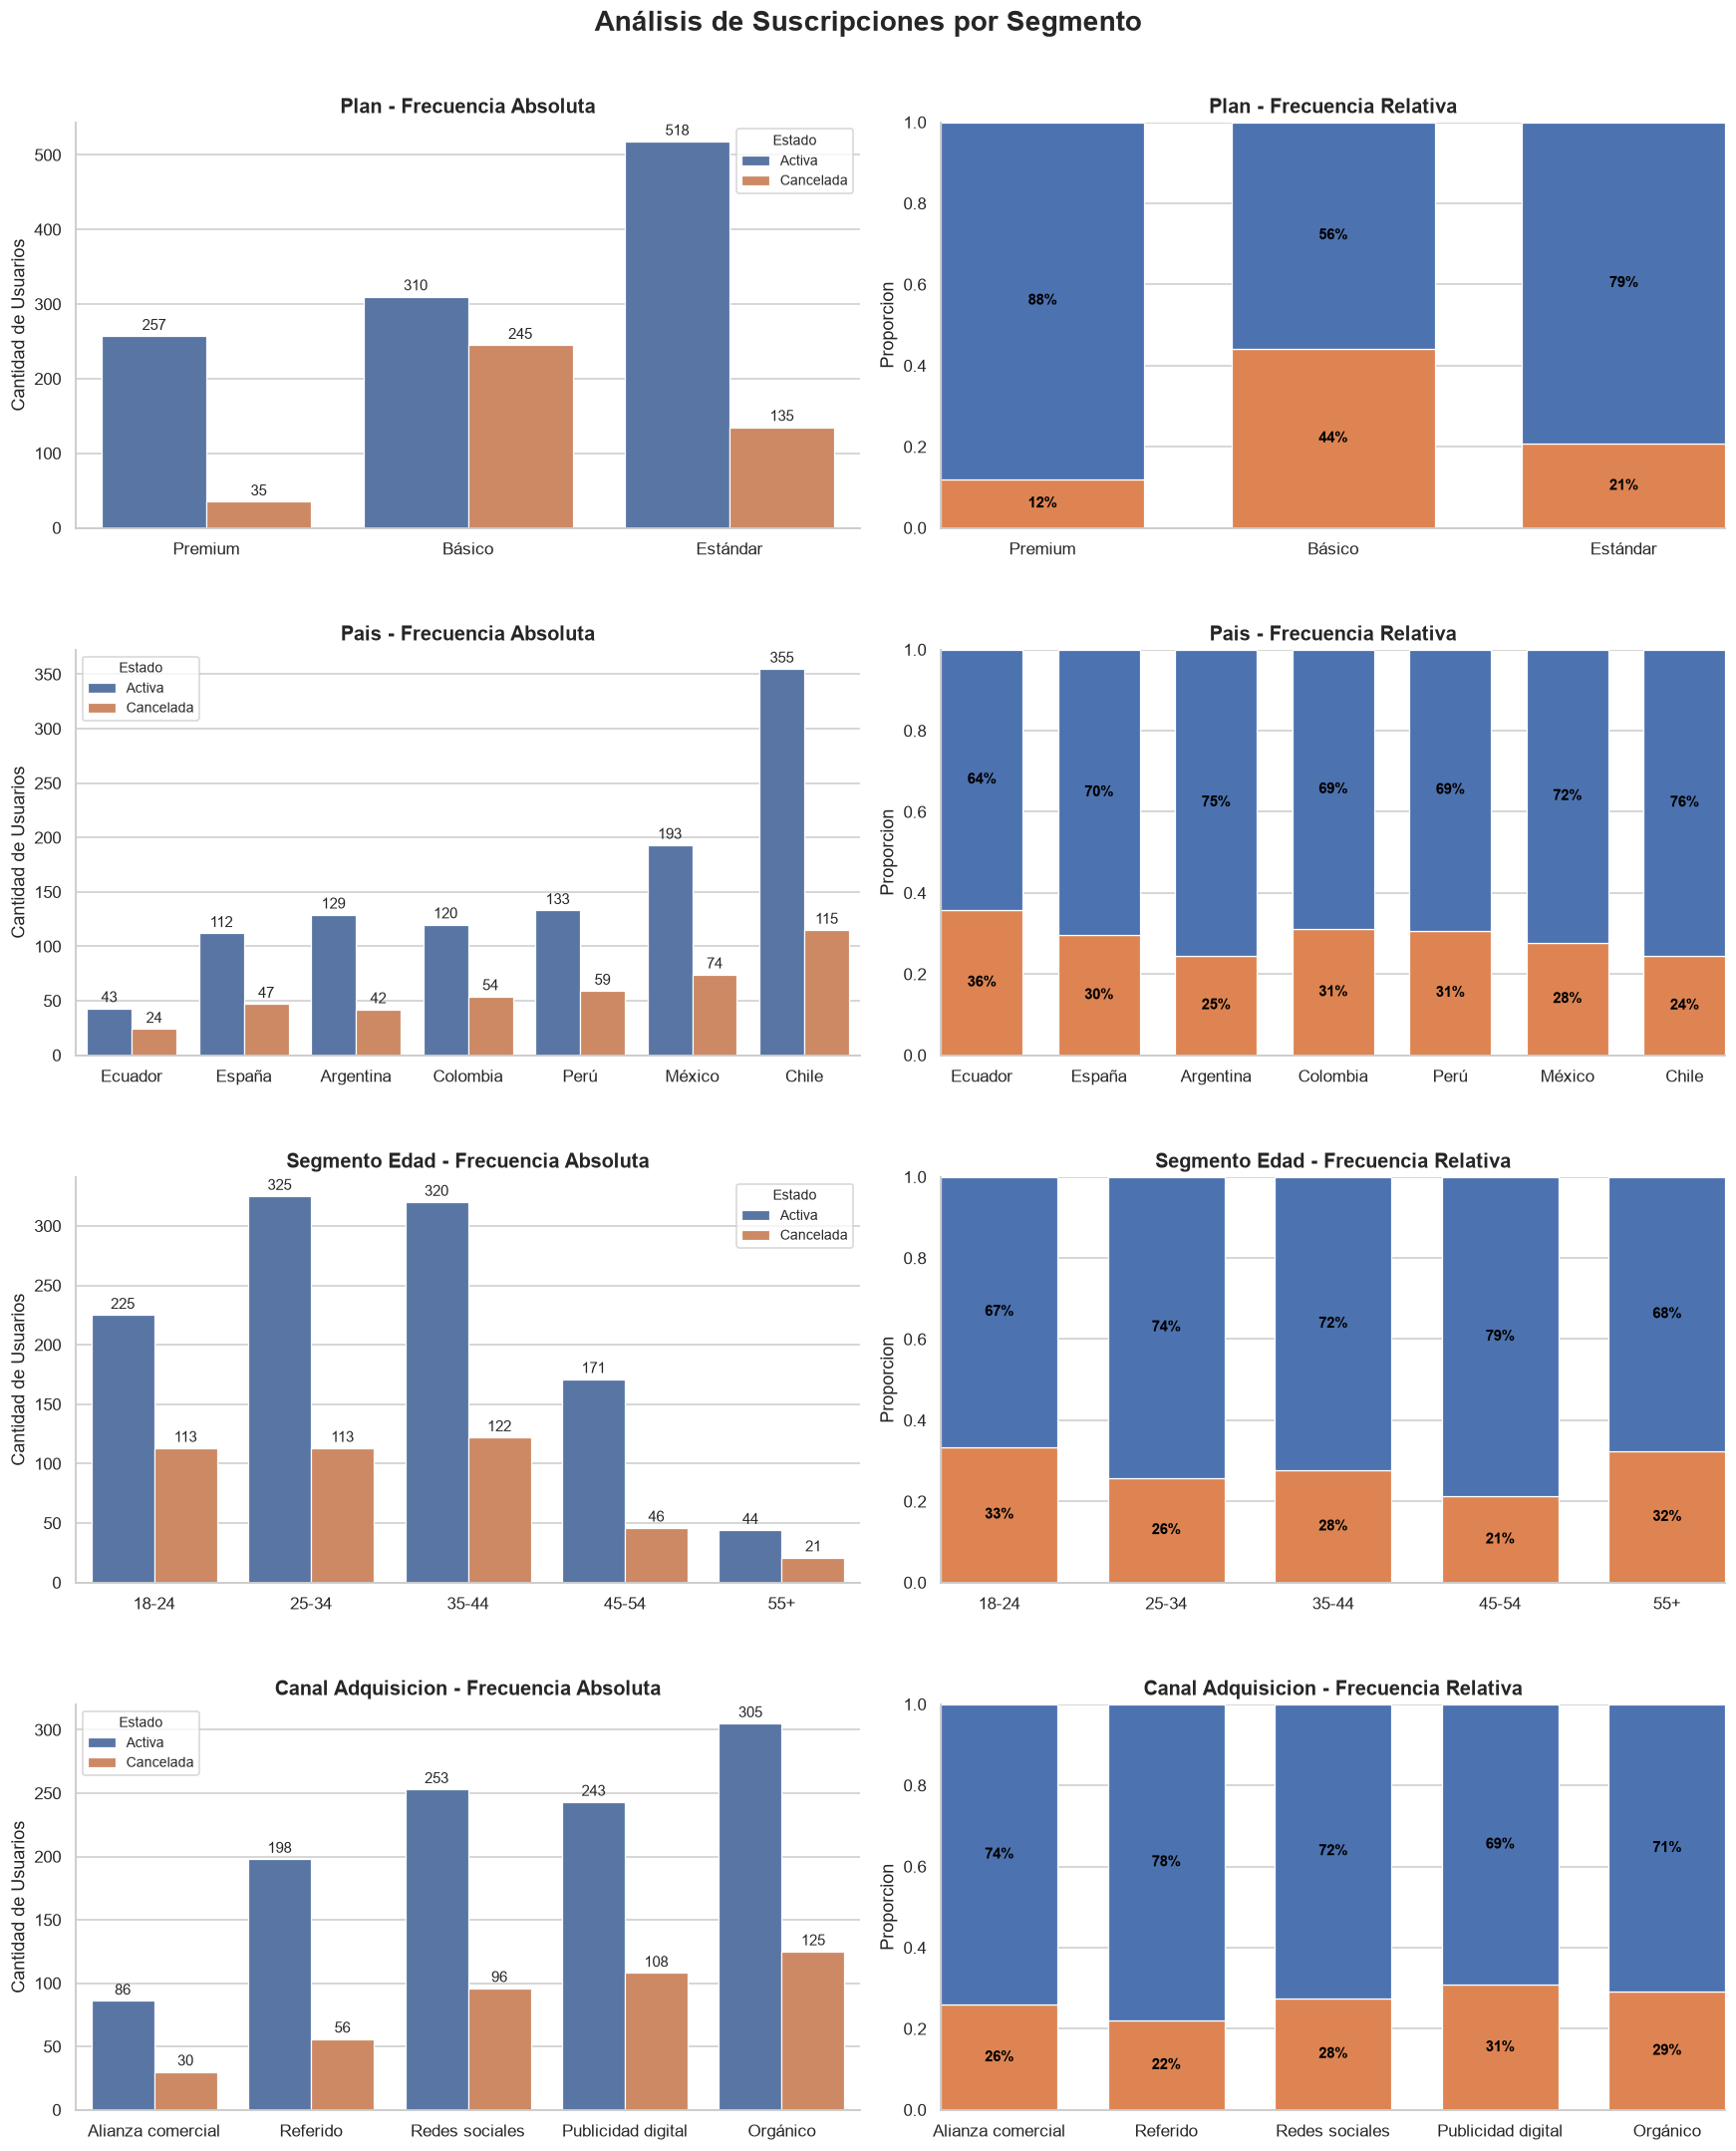

In [9]:
# Suscripcion
df_merged = usuarios.merge(suscripciones, on='usuario_id', how='left')
cols = ['plan', 'pais', 'segmento_edad', 'canal_adquisicion']
n = len(cols)

fig, axes = plt.subplots(n, 2, figsize=(16, 5 * n))

for i, col in enumerate(cols):
    if col == 'segmento_edad':
      orden = df_merged[col].sort_values()
    else:
      orden = df_merged[col].value_counts().sort_values(ascending=True).index

    orden = list(dict.fromkeys(orden))
    titulo = col.replace('_', ' ').title()
    df_merged[f'{col}_ord'] = pd.Categorical(df_merged[col], categories=orden, ordered=True)

    ax_abs = axes[i, 0]
    sns.countplot(data=df_merged, x=col, hue='estado', order=orden,
                  ax=ax_abs, edgecolor='white', linewidth=0.8)

    for container in ax_abs.containers:
      ax_abs.bar_label(container, fontsize=10, padding=2)

    ax_abs.set_title(f'{titulo} - Frecuencia Absoluta', fontsize=13, fontweight='bold')
    ax_abs.set_xlabel('')
    ax_abs.set_ylabel(f'Cantidad de Usuarios')
    ax_abs.legend(title='Estado', frameon=True, fontsize=9, title_fontsize=9)


    ax_rel = axes[i, 1]
    sns.histplot(data=df_merged, x=f'{col}_ord', hue='estado',
                 multiple='fill', shrink=0.7, ax=ax_rel, edgecolor='white', linewidth=0.8, legend=False, alpha=1)
    for container in ax_rel.containers:
      ax_rel.bar_label(container, fmt='%.0f%%',
                       labels=[f'{v.get_height()*100:.0f}%' if v.get_height() > 0.03 else '' for v in container],
                       label_type='center', fontsize=10, color='black', fontweight='bold')

    ax_rel.set_title(f'{titulo} - Frecuencia Relativa', fontsize=13, fontweight='bold')
    ax_rel.set_xlabel('')
    ax_rel.set_ylabel('Proporcion')

fig.suptitle('Análisis de Suscripciones por Segmento', fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.subplots_adjust(hspace=0.3)
plt.show()

df_merged.drop(columns=[f'{col}_ord'], inplace=True)


- **Plan**: Premium retiene muy bien (88%), Estándar razonable (79%), pero Básico tiene fuga alta (44% cancelación) — casi 1 de cada 2 se va.

- **País**: Tasas parejas entre mercados (24%-36% cancelación). Ecuador es el más débil (64% activa), aunque con muestra chica. Argentina y Chile retienen mejor (~75-76%).

- **Segmento de Edad**: 45-54 es el más leal (79% activa). Los extremos —18-24 (67%) y 55+ (68%)— cancelan más: patrón típico de menor compromiso en jóvenes y posible fricción de adopción en mayores.

- **Canal de Adquisición**: Referido retiene mejor (78%) — llegan pre-calificados. Publicidad digital retiene peor (69%, 31% cancelación)

## Reproducciones, minutos vistos, % completado y abandono — *Hernan*

**Responsable:** [Hernan]

**Pregunta del README:** *Reproducciones, minutos vistos, porcentaje completado y abandono.*
**Tablas principales:** `reproducciones`, `contenidos`

**¿Qué queremos analizar?**
Cómo evoluciona el consumo (reproducciones y minutos vistos) durante 2025, qué tan completos son los visionados (`porcentaje_completado`) y qué factores —dispositivo, calidad de video, buffering, tipo de contenido— se asocian al abandono temprano (`abandono_temprano`, definido como <20% de avance).

#### Preparación de datos

In [10]:
reproducciones['fecha_hora_inicio'] = pd.to_datetime(reproducciones['fecha_hora_inicio'])
reproducciones['mes'] = reproducciones['fecha_hora_inicio'].dt.to_period('M').astype(str)

rep_full = reproducciones.merge(
    contenidos[['contenido_id', 'titulo', 'tipo_contenido', 'genero_principal']],
    on='contenido_id', how='left'
)

print(f"Reproducciones totales: {len(rep_full):,}")
print(f"Usuarios distintos que reprodujeron: {rep_full['usuario_id'].nunique():,}")
print(f"Contenidos distintos reproducidos: {rep_full['contenido_id'].nunique():,}")
print(f"Minutos totales vistos en el período: {rep_full['minutos_reproducidos'].sum():,.0f} min")
print(f"Tasa de abandono temprano global: {(rep_full['abandono_temprano']=='Sí').mean()*100:.2f}%")

Reproducciones totales: 25,000
Usuarios distintos que reprodujeron: 1,500
Contenidos distintos reproducidos: 420
Minutos totales vistos en el período: 1,423,491 min
Tasa de abandono temprano global: 0.40%


#### Evolución mensual de reproducciones y minutos vistos

**¿Por qué este gráfico?** Para ver evolución en el tiempo, la línea temporal es el tipo de gráfico más directo (posición en eje X = tiempo), y usamos dos paneles alineados en vez de un eje doble, para no distorsionar la comparación visual entre dos escalas distintas (buena práctica: evitar doble eje Y engañoso).

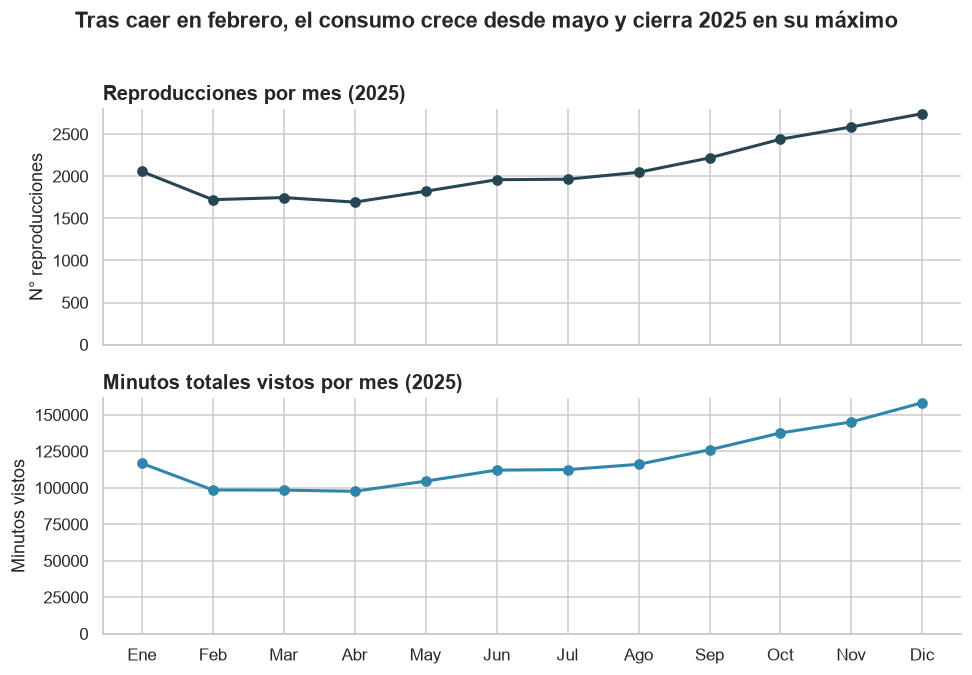

Diciembre vs. enero: +35.6%
Diciembre vs. abril (mínimo del año): +62.2%
2.º semestre vs. 1.er semestre: +26.7%


In [11]:
mensual = rep_full.groupby('mes').agg(
    n_reproducciones=('reproduccion_id', 'count'),
    minutos_totales=('minutos_reproducidos', 'sum')
).reset_index()
MESES = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
mensual['mes_nombre'] = [MESES[int(m[-2:]) - 1] for m in mensual['mes']]

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

axes[0].plot(mensual['mes_nombre'], mensual['n_reproducciones'], marker='o', color=COLOR_LINEA, linewidth=2)
axes[0].set_title('Reproducciones por mes (2025)', loc='left')
axes[0].set_ylabel('N° reproducciones')
axes[0].set_ylim(bottom=0)

axes[1].plot(mensual['mes_nombre'], mensual['minutos_totales'], marker='o', color=COLOR_ACENTO_POS, linewidth=2)
axes[1].set_title('Minutos totales vistos por mes (2025)', loc='left')
axes[1].set_ylabel('Minutos vistos')
axes[1].set_ylim(bottom=0)

fig.suptitle('Tras caer en febrero, el consumo crece desde mayo y cierra 2025 en su máximo', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

minutos = mensual['minutos_totales']
print(f"Diciembre vs. enero: {(minutos.iloc[-1] / minutos.iloc[0] - 1) * 100:+.1f}%")
print(f"Diciembre vs. abril (mínimo del año): {(minutos.iloc[-1] / minutos.min() - 1) * 100:+.1f}%")
print(f"2.º semestre vs. 1.er semestre: {(minutos.iloc[6:].sum() / minutos.iloc[:6].sum() - 1) * 100:+.1f}%")

**Hallazgo:** reproducciones y minutos se mueven en paralelo (r = 0,998). Enero parte alto (116.734 minutos), febrero cae 16% y el consumo se mantiene plano hasta abril, el mínimo del año (97.599). Desde mayo crece casi todos los meses (julio queda plano) y se acelera desde septiembre: diciembre cierra con 158.315 minutos, el máximo del año, +62% sobre abril y +36% sobre enero.

**¿Qué significa para StreamView?** El segundo semestre es claramente más fuerte (+27% de minutos que el primero). El alza viene más de la intensidad que de la base: los usuarios que reproducen en el mes suben 14% entre enero y diciembre, mientras las reproducciones suben 33%. Conviene cruzar esto con retención (4.1), porque más consumo no garantiza más suscriptores activos.

#### Distribución del porcentaje completado

**¿Por qué este gráfico?** Un histograma es la forma estándar de mostrar la forma de una distribución continua (asimetría, concentración), mejor que un promedio único que oculta la dispersión.

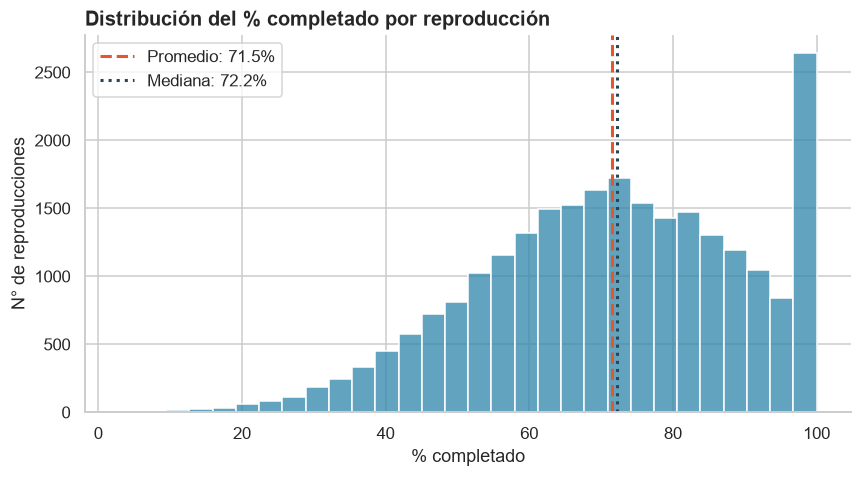

In [12]:
media_pct = rep_full['porcentaje_completado'].mean()
mediana_pct = rep_full['porcentaje_completado'].median()

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(rep_full['porcentaje_completado'], bins=30, color=COLOR_ACENTO_POS, ax=ax)
ax.axvline(media_pct, color=COLOR_ACENTO, linestyle='--', linewidth=2, label=f'Promedio: {media_pct:.1f}%')
ax.axvline(mediana_pct, color=COLOR_LINEA, linestyle=':', linewidth=2, label=f'Mediana: {mediana_pct:.1f}%')
ax.set_title('Distribución del % completado por reproducción', loc='left', fontweight='bold')
ax.set_xlabel('% completado')
ax.set_ylabel('N° de reproducciones')
ax.legend()
plt.tight_layout()
plt.show()

**Hallazgo:** el % completado promedio es 71,5% y la mediana 72,2%. La mitad central de las reproducciones está entre 59% y 86% completado. La cola baja (menos de 20% de avance) es pequeña en volumen, 99 de 25.000 reproducciones (0,4%), pero es el "abandono duro" que analizamos a continuación.

**¿Qué significa para StreamView?** La mayoría de las reproducciones sí retienen a los usuarios más allá de la mitad del contenido; el problema de abandono, más que masivo, está concentrado en condiciones específicas (dispositivo, calidad), que revisamos en los siguientes gráficos.

#### Completado y abandono temprano según tipo de dispositivo

**¿Por qué este gráfico?** Barras horizontales ordenadas por valor son el tipo de gráfico más eficiente para comparar una métrica entre pocas categorías (5 tipos de dispositivo). Usamos color de acento sólo en la categoría con peor desempeño para dirigir la atención (jerarquía visual).

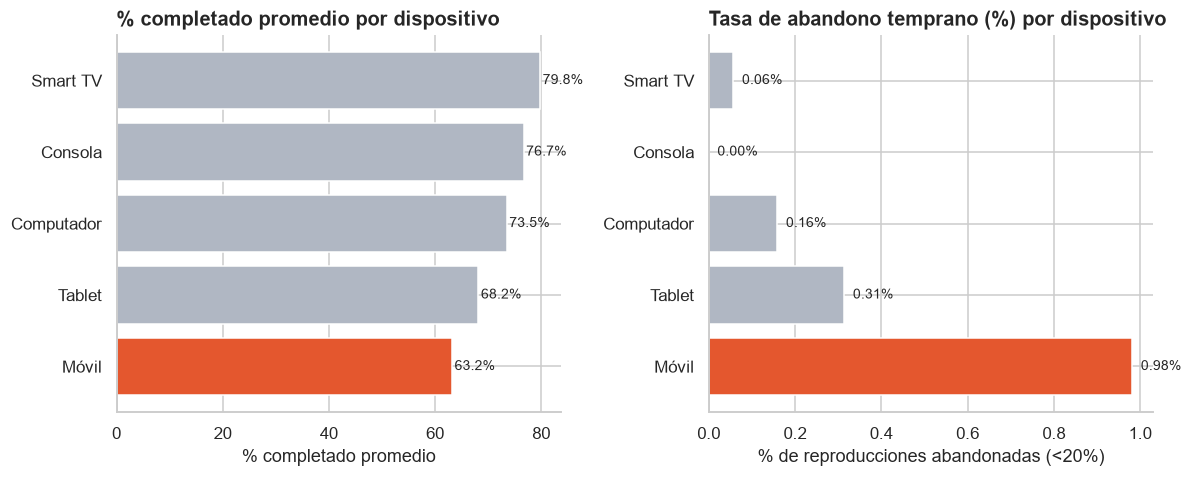

In [13]:
pct_disp = rep_full.groupby('tipo_dispositivo')['porcentaje_completado'].mean().sort_values()
aband_disp = rep_full.groupby('tipo_dispositivo')['abandono_temprano'].apply(lambda x: (x == 'Sí').mean() * 100).reindex(pct_disp.index)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

colores1 = [COLOR_ACENTO if d == pct_disp.idxmin() else COLOR_NEUTRO for d in pct_disp.index]
axes[0].barh(pct_disp.index, pct_disp.values, color=colores1)
axes[0].set_title('% completado promedio por dispositivo', loc='left', fontweight='bold')
axes[0].set_xlabel('% completado promedio')
for i, v in enumerate(pct_disp.values):
    axes[0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

colores2 = [COLOR_ACENTO if d == aband_disp.idxmax() else COLOR_NEUTRO for d in aband_disp.index]
axes[1].barh(aband_disp.index, aband_disp.values, color=colores2)
axes[1].set_title('Tasa de abandono temprano (%) por dispositivo', loc='left', fontweight='bold')
axes[1].set_xlabel('% de reproducciones abandonadas (<20%)')
for i, v in enumerate(aband_disp.values):
    axes[1].text(v + 0.02, i, f'{v:.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

**Hallazgo:** Móvil es el dispositivo más usado (30,6% de las reproducciones) y el de peor experiencia: tiene el menor % completado (63,2% contra 79,8% en Smart TV) y la mayor tasa de abandono temprano (0,98%). Con menos de un tercio de las reproducciones, concentra 75 de los 99 abandonos del año (76%). Móvil y Tablet duplican el buffering promedio del resto (≈11,5 s contra ≈5,8 s).

**¿Qué significa para StreamView?** El problema de abandono no es general: se concentra en las pantallas móviles, justamente donde más se consume. Mejorar la reproducción en móvil (precarga, calidad adaptativa, recuperación ante cortes) ataca el 76% del abandono con un solo frente de trabajo.

#### Calidad de video, buffering y % completado

**¿Por qué este gráfico?** Para una relación entre dos variables continuas (buffering y % completado) usamos un gráfico de dispersión con línea de tendencia, que permite ver tanto la forma de la relación como su fuerza aproximada. La calidad de video se resume en una tabla porque son solo 4 categorías con 3 métricas cada una.

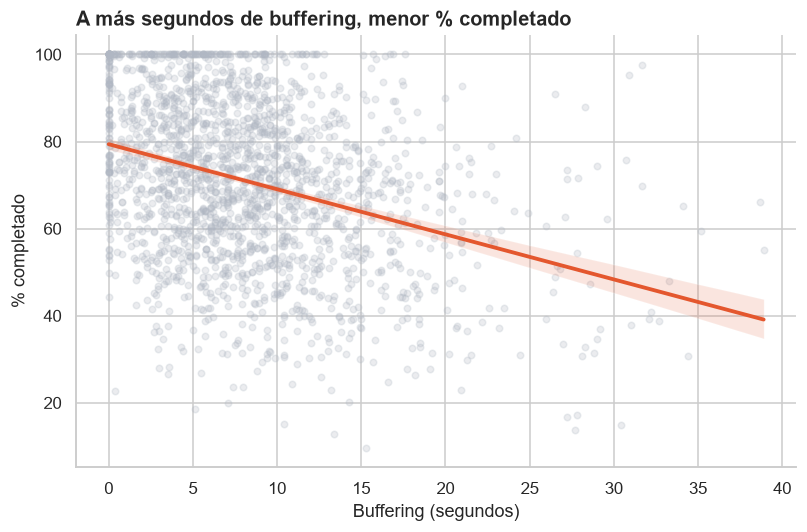

Correlación buffering vs. % completado: -0.31

% completado promedio y buffering promedio por calidad de video:


,pct_completado_prom,buffering_prom,tasa_abandono
calidad_video,,,
SD,71.25,8.13,0.51
HD,71.21,8.26,0.37
Full HD,71.55,7.99,0.42
4K,72.38,9.04,0.32


In [14]:
muestra = rep_full.sample(2000, random_state=42)

fig, ax = plt.subplots(figsize=(7.5, 5))
sns.regplot(
    data=muestra, x='buffering_segundos', y='porcentaje_completado',
    scatter_kws={'alpha': 0.25, 'color': COLOR_NEUTRO, 's': 18},
    line_kws={'color': COLOR_ACENTO, 'linewidth': 2.5}, ax=ax
)
ax.set_title('A más segundos de buffering, menor % completado', loc='left', fontweight='bold')
ax.set_xlabel('Buffering (segundos)')
ax.set_ylabel('% completado')
plt.tight_layout()
plt.show()

corr_buffering = rep_full[['buffering_segundos', 'porcentaje_completado']].corr().iloc[0, 1]
print(f"Correlación buffering vs. % completado: {corr_buffering:.2f}")

print()
print("% completado promedio y buffering promedio por calidad de video:")
orden_calidad = ['SD', 'HD', 'Full HD', '4K']
resumen_calidad = rep_full.groupby('calidad_video').agg(
    pct_completado_prom=('porcentaje_completado', 'mean'),
    buffering_prom=('buffering_segundos', 'mean'),
    tasa_abandono=('abandono_temprano', lambda x: (x == 'Sí').mean() * 100)
).reindex(orden_calidad)

resumen_calidad.round(2)

**Hallazgo:** hay una correlación negativa moderada (r ≈ −0,31) entre los segundos de buffering y el % completado: a más interrupciones, menor avance en el contenido. La calidad de video, en cambio, casi no cambia el % completado (71,2% a 72,4%). El abandono temprano es menor en 4K (0,32%) y mayor en SD (0,51%), pero no baja de forma pareja: Full HD (0,42%) supera a HD (0,37%). Son diferencias de décimas basadas en pocos casos (entre 10 y 44 abandonos por calidad), así que la calidad de video no aparece como un factor fuerte. El buffering sí lo es.

**¿Qué significa para StreamView?** El buffering no es solo una molestia técnica: se asocia de forma medible a menor consumo efectivo. Junto con el hallazgo de dispositivo (4.2.4), la experiencia técnica aparece como una palanca de consumo efectivo (engagement). Su efecto sobre la retención es una hipótesis a validar: en estos datos, el buffering promedio de un usuario no se asocia con haber cancelado.

#### Completado según tipo de contenido

**¿Por qué este gráfico?** Barras verticales simples: comparación directa entre 3 categorías (Película, Serie, Documental).

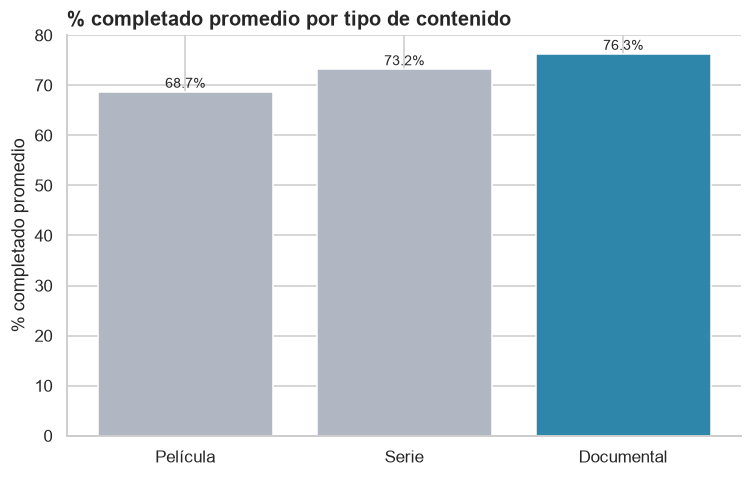

Minutos reproducidos promedio por sesión, según tipo de contenido:


tipo_contenido
Película      79.8
Serie         31.1
Documental    57.1
Name: minutos_reproducidos, dtype: float64

In [15]:
pct_tipo = rep_full.groupby('tipo_contenido')['porcentaje_completado'].mean().sort_values()
min_tipo = rep_full.groupby('tipo_contenido')['minutos_reproducidos'].mean().reindex(pct_tipo.index)

fig, ax = plt.subplots(figsize=(7, 4.5))
colores = [COLOR_ACENTO_POS if t == pct_tipo.idxmax() else COLOR_NEUTRO for t in pct_tipo.index]
bars = ax.bar(pct_tipo.index, pct_tipo.values, color=colores)
ax.set_title('% completado promedio por tipo de contenido', loc='left', fontweight='bold')
ax.set_ylabel('% completado promedio')
for b, v in zip(bars, pct_tipo.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.8, f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print("Minutos reproducidos promedio por sesión, según tipo de contenido:")

min_tipo.round(1)

**Hallazgo:** los Documentales (76,3%) y Series (73,2%) se completan más que las Películas (68,7%). Al mismo tiempo, las películas tienen sesiones más largas en minutos (más duración por reproducción), mientras que las series se ven en episodios cortos pero con mayor tasa de avance relativo.

**¿Qué significa para StreamView?** El formato episódico (series/documentales) parece generar sesiones más "completas" — coherente con un consumo tipo maratón de episodios cortos. Las películas, al requerir un bloque de tiempo más largo y continuo, tienen más riesgo de quedar a medio ver. Esto es un insumo directo para el equipo de contenido (línea 4.3): no basta con mirar qué género gusta más, también importa el formato.

#### Contenidos más reproducidos

**¿Por qué este gráfico?** Ranking Top-N: barras horizontales ordenadas, la forma más legible para "leer" un ranking con etiquetas de texto largas (títulos).

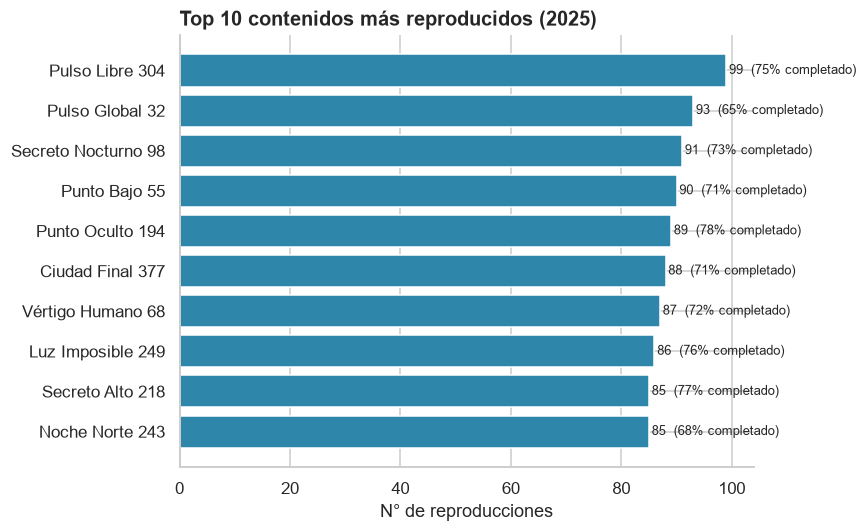

In [16]:
top10 = (
    rep_full.groupby('titulo')
    .agg(n_reproducciones=('reproduccion_id', 'count'), pct_completado_prom=('porcentaje_completado', 'mean'))
    .sort_values('n_reproducciones', ascending=False)
    .head(10)
    .sort_values('n_reproducciones')
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top10.index, top10['n_reproducciones'], color=COLOR_ACENTO_POS)
ax.set_title('Top 10 contenidos más reproducidos (2025)', loc='left', fontweight='bold')
ax.set_xlabel('N° de reproducciones')
for i, (v, pct) in enumerate(zip(top10['n_reproducciones'], top10['pct_completado_prom'])):
    ax.text(v + 0.5, i, f'{v}  ({pct:.0f}% completado)', va='center', fontsize=8.5)
plt.tight_layout()
plt.show()

**Hallazgo:** la popularidad no siempre acompaña al % completado: 4 de los 10 títulos más vistos quedan bajo el promedio general de 71,5%, por ejemplo *Pulso Global 32* (93 reproducciones, 65,1%) y *Noche Norte 243* (85 reproducciones, 67,7%). Esto se retoma formalmente en 4.5.5 (popularidad vs. satisfacción).

**¿Qué significa para StreamView?** El volumen de reproducciones por sí solo no certifica que un contenido "funcione bien"; conviene mirarlo siempre junto al % completado antes de decidir renovar licencias o promocionar un título en la portada.

#### Recomendaciones

1. Priorizar mejoras de experiencia en **Móvil** (precarga, reproducción adaptativa, recuperación ante cortes): concentra el 76% del abandono temprano y el menor % completado.
2. Monitorear el **buffering** como KPI de calidad de servicio, no solo como métrica de infraestructura: está asociado a menor consumo efectivo.
3. Al evaluar el desempeño de un contenido, reportar siempre **reproducciones + % completado juntos**, no el volumen por sí solo.

### Preferencias de contenido — 🔲 *Pendiente*

### Experiencia técnica por dispositivo — 🔲 *Pendiente*

### 4.5 Relación entre consumo, interacciones y calificaciones — ✅ *Hernan*

**Responsable:** [Hernan]
**Pregunta del README:** *Relación entre consumo, interacciones y calificaciones.*
**Tablas principales:** `reproducciones`, `interacciones`, `calificaciones`

**¿Qué queremos analizar?**
Si consumir más (reproducciones, minutos, % completado) se relaciona con interactuar más (me gusta, compartir, agregar a lista) y con calificar mejor. La hipótesis de negocio habitual es *"quien más ve, más le gusta, mejor califica y más recomienda"* — la ponemos a prueba con los datos.

### Preparación: agregados a nivel usuario, contenido y par usuario–contenido

In [17]:
# --- Nivel usuario ---
cons_usr = reproducciones.groupby('usuario_id').agg(
    n_reproducciones=('reproduccion_id', 'count'),
    minutos_totales=('minutos_reproducidos', 'sum'),
    pct_completado_prom=('porcentaje_completado', 'mean')
).reset_index()

inter_usr = interacciones.groupby('usuario_id').agg(n_interacciones=('interaccion_id', 'count')).reset_index()
me_gusta_usr = interacciones[interacciones['tipo_interaccion'] == 'Me gusta'].groupby('usuario_id').size().rename('n_me_gusta')

calif_usr = calificaciones.groupby('usuario_id').agg(
    n_calificaciones=('calificacion_id', 'count'),
    puntuacion_prom=('puntuacion_1_5', 'mean')
).reset_index()
recomend_usr = calificaciones.groupby('usuario_id')['recomendaria'].apply(lambda x: (x == 'Sí').mean()).rename('tasa_recomendaria')

usuario_360 = (
    cons_usr.merge(inter_usr, on='usuario_id', how='left')
            .merge(calif_usr, on='usuario_id', how='left')
            .merge(me_gusta_usr, on='usuario_id', how='left')
            .merge(recomend_usr, on='usuario_id', how='left')
)
# Conteos sin registros = 0. Los PROMEDIOS de quien nunca calificó quedan vacíos (NaN):
# rellenarlos con 0 inventa una correlación entre N° de calificaciones y puntuación.
conteos_usr = [c for c in usuario_360.columns if c.startswith('n_')]
usuario_360[conteos_usr] = usuario_360[conteos_usr].fillna(0)

# --- Nivel contenido ---
cons_cont = reproducciones.groupby('contenido_id').agg(
    n_reproducciones=('reproduccion_id', 'count'),
    minutos_totales=('minutos_reproducidos', 'sum'),
    pct_completado_prom=('porcentaje_completado', 'mean')
).reset_index()
inter_cont = interacciones.groupby('contenido_id').agg(n_interacciones=('interaccion_id', 'count')).reset_index()
calif_cont = calificaciones.groupby('contenido_id').agg(
    n_calificaciones=('calificacion_id', 'count'),
    puntuacion_prom=('puntuacion_1_5', 'mean')
).reset_index()

contenido_360 = (
    cons_cont.merge(inter_cont, on='contenido_id', how='left')
             .merge(calif_cont, on='contenido_id', how='left')
)
conteos_cont = [c for c in contenido_360.columns if c.startswith('n_')]
contenido_360[conteos_cont] = contenido_360[conteos_cont].fillna(0)

# --- Nivel par usuario-contenido: cruzamos cada calificación con el % completado
#     que ese mismo usuario tuvo en ese mismo contenido ---
rep_pair = reproducciones.groupby(['usuario_id', 'contenido_id'])['porcentaje_completado'].mean().reset_index()
calif_pair = calificaciones.merge(rep_pair, on=['usuario_id', 'contenido_id'], how='inner')

print(f"Usuarios con vista 360°: {len(usuario_360):,}")
print(f"  de ellos sin calificaciones (quedan fuera de las correlaciones de puntuación): {usuario_360['puntuacion_prom'].isna().sum():,}")
print(f"Contenidos con vista 360°: {len(contenido_360):,}")
print(f"Pares calificación-reproducción cruzados: {len(calif_pair):,} de {len(calificaciones):,} calificaciones")

Usuarios con vista 360°: 1,500
  de ellos sin calificaciones (quedan fuera de las correlaciones de puntuación): 238
Contenidos con vista 360°: 420
Pares calificación-reproducción cruzados: 3,119 de 3,119 calificaciones


#### % Completado vs. Puntuación entregada (el mismo usuario, el mismo contenido)

**¿Por qué este gráfico?** Este es el cruce más directo posible: para cada calificación, miramos cuánto completó ese usuario ese contenido específico. Usamos barras porque `puntuacion_1_5` es una escala discreta de 5 categorías ordinales.

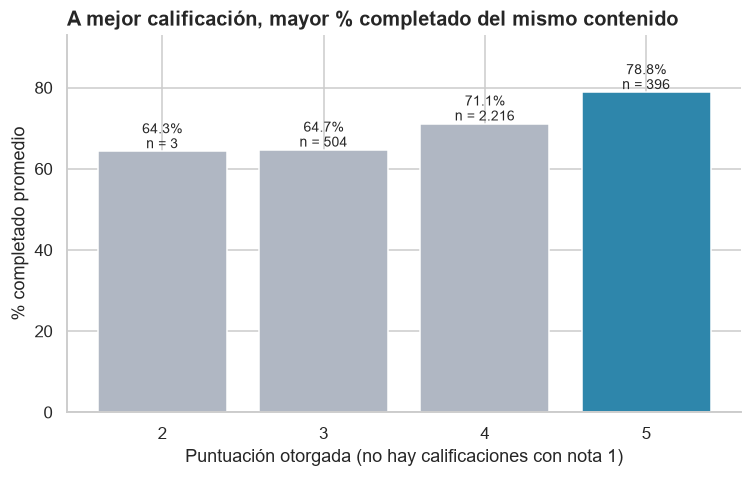

Correlación puntuación vs. % completado (a nivel par usuario-contenido): 0.20


In [18]:
por_puntuacion = calif_pair.groupby('puntuacion_1_5').agg(
    pct=('porcentaje_completado', 'mean'),
    n=('calificacion_id', 'count')
)

fig, ax = plt.subplots(figsize=(7, 4.5))
colores = [COLOR_ACENTO_POS if p == por_puntuacion.index.max() else COLOR_NEUTRO for p in por_puntuacion.index]
bars = ax.bar(por_puntuacion.index.astype(str), por_puntuacion['pct'], color=colores)
ax.set_title('A mejor calificación, mayor % completado del mismo contenido', loc='left', fontweight='bold')
ax.set_xlabel('Puntuación otorgada (no hay calificaciones con nota 1)')
ax.set_ylabel('% completado promedio')
ax.set_ylim(0, por_puntuacion['pct'].max() * 1.18)
for b, (v, n) in zip(bars, por_puntuacion[['pct', 'n']].itertuples(index=False)):
    ax.text(b.get_x() + b.get_width()/2, v + 0.8, f'{v:.1f}%\nn = {n:,}'.replace(',', '.'), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

corr_pair = calif_pair[['puntuacion_1_5', 'porcentaje_completado']].corr().iloc[0, 1]
print(f"Correlación puntuación vs. % completado (a nivel par usuario-contenido): {corr_pair:.2f}")

**Hallazgo:** esta es la relación más clara de la sección. El % completado sube con la puntuación: de 64,7% con nota 3 (504 calificaciones) a 71,1% con nota 4 (2.216) y 78,8% con nota 5 (396). La nota 2 tiene solo 3 casos y no se usa para concluir; no hay calificaciones con nota 1. La correlación es débil (0,20), pero el patrón es monotónico.

**¿Qué significa para StreamView?** El **comportamiento real de visionado (% completado) es un buen termómetro de satisfacción**: quienes terminan el contenido, en promedio, lo valoran mejor. Esto abre una oportunidad de negocio: usar el % completado como *proxy* de satisfacción en tiempo real, sin depender de que el usuario se tome el tiempo de calificar (solo el 12,7% de las reproducciones tiene una calificación asociada).

#### ¿El volumen de consumo se relaciona con interactuar y calificar mejor? (nivel usuario y nivel contenido)

**¿Por qué este gráfico?** Un mapa de calor de correlaciones permite ver de un vistazo si existe o no relación lineal entre muchas variables a la vez, sin tener que armar un gráfico de dispersión por cada par.

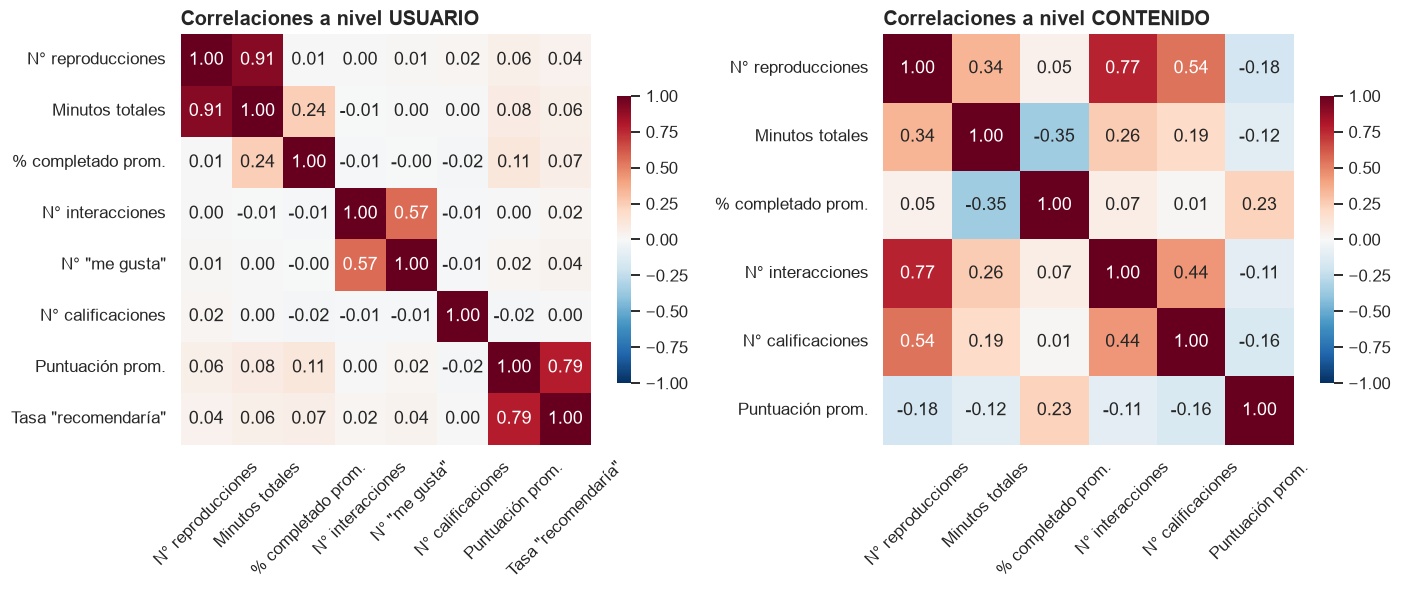

In [19]:
cols_usr = ['n_reproducciones', 'minutos_totales', 'pct_completado_prom',
            'n_interacciones', 'n_me_gusta', 'n_calificaciones', 'puntuacion_prom', 'tasa_recomendaria']
cols_cont = ['n_reproducciones', 'minutos_totales', 'pct_completado_prom',
             'n_interacciones', 'n_calificaciones', 'puntuacion_prom']

etiquetas = {
    'n_reproducciones': 'N° reproducciones', 'minutos_totales': 'Minutos totales',
    'pct_completado_prom': '% completado prom.', 'n_interacciones': 'N° interacciones',
    'n_me_gusta': 'N° "me gusta"', 'n_calificaciones': 'N° calificaciones',
    'puntuacion_prom': 'Puntuación prom.', 'tasa_recomendaria': 'Tasa "recomendaría"'
}

corr_usr = usuario_360[cols_usr].corr().rename(columns=etiquetas, index=etiquetas)
corr_cont = contenido_360[cols_cont].corr().rename(columns=etiquetas, index=etiquetas)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
sns.heatmap(corr_usr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={'shrink': .7}, ax=axes[0])
axes[0].set_title('Correlaciones a nivel USUARIO', loc='left', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(corr_cont, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={'shrink': .7}, ax=axes[1])
axes[1].set_title('Correlaciones a nivel CONTENIDO', loc='left', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Hallazgo:** a **nivel usuario**, cuánto reproduce o cuántos minutos acumula un usuario casi no se relaciona con cuánto interactúa (≈0,00) ni con cómo califica (0,06 a 0,08): **ver mucho no implica interactuar más ni calificar mejor.** Tampoco califican más alto quienes califican más seguido (−0,02). La única señal, débil, es que quien completa más lo que ve califica algo mejor (0,11), coherente con 4.5.2. *Nota: los 238 usuarios que nunca calificaron no entran en las correlaciones de puntuación y recomendación; sus promedios no se rellenan con 0.*

A **nivel contenido** el patrón es distinto: más reproducciones traen más interacciones (0,77), algo esperable por exposición, pero la relación con la puntuación es débil y **negativa** (−0,18): los contenidos más vistos no son necesariamente los mejor evaluados.

**¿Qué significa para StreamView?** El volumen de consumo (a nivel usuario) **no es un buen indicador de satisfacción o de propensión a recomendar**; son fenómenos relativamente independientes. Para retención y NPS, StreamView necesita mirar señales de calidad de la experiencia (como el % completado de 4.5.2) y no solo cuánto tiempo pasa el usuario en la app.

### ¿Reaccionar ("me gusta" / "no me gusta" / agregar a lista) se relaciona con calificar mejor ese mismo contenido?

**¿Por qué este gráfico?** Comparación de un promedio (puntuación) entre dos grupos (dejó vs. no dejó la interacción) → barras agrupadas, ideal para contrastes binarios simples.

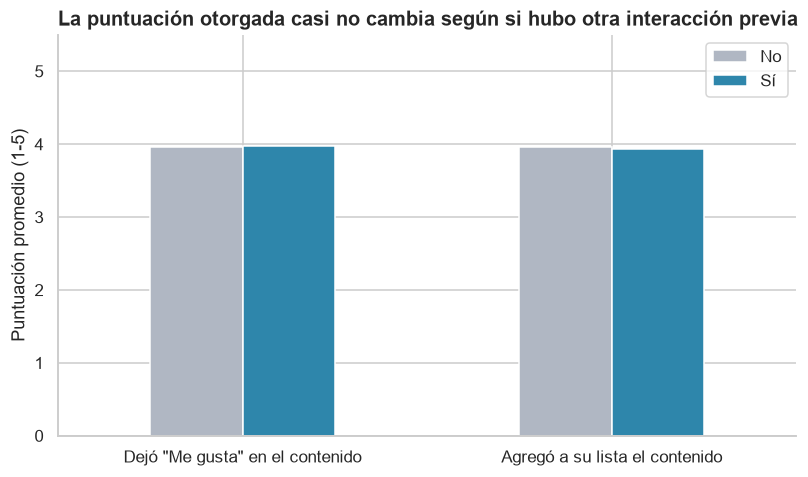

,"Dejó ""Me gusta"" en el contenido",Agregó a su lista el contenido
No,3.96,3.97
Sí,3.97,3.94


In [20]:
def flag_interaccion(tipo, nombre_col):
    pares = interacciones[interacciones['tipo_interaccion'] == tipo][['usuario_id', 'contenido_id']].drop_duplicates()
    pares[nombre_col] = True
    return pares

calif_flags = calif_pair.merge(flag_interaccion('Me gusta', 'dejo_me_gusta'), on=['usuario_id', 'contenido_id'], how='left')
calif_flags = calif_flags.merge(flag_interaccion('Agregar a mi lista', 'agrego_lista'), on=['usuario_id', 'contenido_id'], how='left')
calif_flags[['dejo_me_gusta', 'agrego_lista']] = calif_flags[['dejo_me_gusta', 'agrego_lista']].fillna(False)

resumen_flags = pd.DataFrame({
    'Dejó "Me gusta" en el contenido': calif_flags.groupby('dejo_me_gusta')['puntuacion_1_5'].mean(),
    'Agregó a su lista el contenido': calif_flags.groupby('agrego_lista')['puntuacion_1_5'].mean(),
})
resumen_flags.index = ['No', 'Sí']

fig, ax = plt.subplots(figsize=(7.5, 4.5))
resumen_flags.T.plot(kind='bar', ax=ax, color=[COLOR_NEUTRO, COLOR_ACENTO_POS], rot=0)
ax.set_title('La puntuación otorgada casi no cambia según si hubo otra interacción previa', loc='left', fontweight='bold')
ax.set_ylabel('Puntuación promedio (1-5)')
ax.set_ylim(0, 5.5)
ax.legend(title='')
plt.tight_layout()
plt.show()

resumen_flags.round(2)

**Hallazgo:** la puntuación promedio casi no varía según si el usuario dejó "Me gusta" (3,97 vs. 3,96) o agregó el contenido a su lista (3,94 vs. 3,97) en ese mismo título. Estas interacciones "declarativas" rápidas no distinguen bien entre quienes califican alto y bajo.

**¿Qué significa para StreamView?** Confirma el hallazgo de completado vs. puntuación entregada desde otro ángulo: las **interacciones de un clic** (me gusta, agregar a lista) son señales débiles de satisfacción real, mientras que el **comportamiento de consumo** (% completado) sí distingue claramente. Si el equipo de Producto necesita un indicador temprano de satisfacción, el consumo real es más confiable que los contadores de "me gusta".

#### Popularidad vs. satisfacción a nivel de contenido

**¿Por qué este gráfico?** Dispersión con tamaño de punto: permite ver simultáneamente 3 variables (reproducciones en X, puntuación en Y, volumen de calificaciones en el tamaño del punto) sin saturar el gráfico.

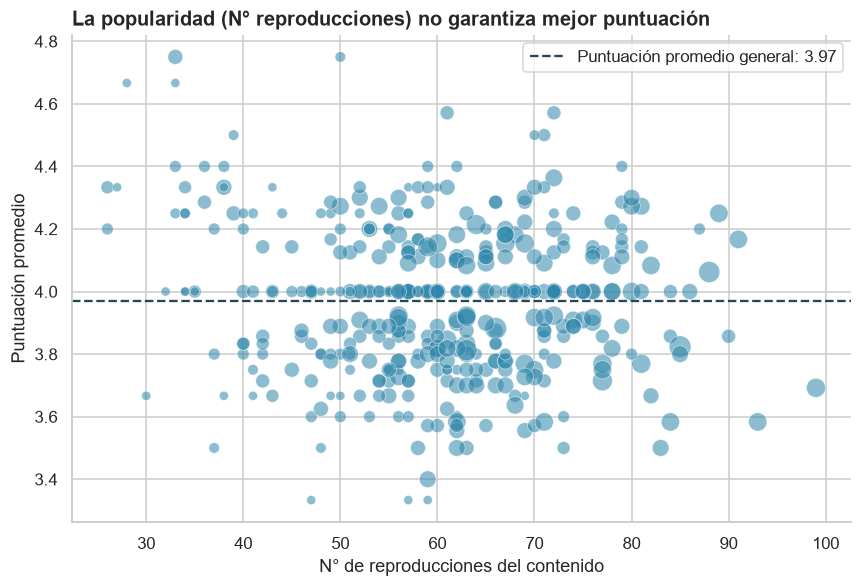

Contenidos con 3 o más calificaciones: 405 · correlación reproducciones vs. puntuación: -0.11


In [21]:
plot_df = contenido_360[contenido_360['n_calificaciones'] >= 3]

fig, ax = plt.subplots(figsize=(8, 5.5))
sc = ax.scatter(
    plot_df['n_reproducciones'], plot_df['puntuacion_prom'],
    s=plot_df['n_calificaciones'] * 12, alpha=0.55,
    color=COLOR_ACENTO_POS, edgecolor='white', linewidth=0.5
)
ax.set_title('La popularidad (N° reproducciones) no garantiza mejor puntuación', loc='left', fontweight='bold')
ax.set_xlabel('N° de reproducciones del contenido')
ax.set_ylabel('Puntuación promedio')
ax.axhline(plot_df['puntuacion_prom'].mean(), color=COLOR_LINEA, linestyle='--', linewidth=1.5,
           label=f'Puntuación promedio general: {plot_df["puntuacion_prom"].mean():.2f}')
ax.legend()
plt.tight_layout()
plt.show()

corr_pop = plot_df['n_reproducciones'].corr(plot_df['puntuacion_prom'])
print(f"Contenidos con 3 o más calificaciones: {len(plot_df)} · correlación reproducciones vs. puntuación: {corr_pop:.2f}")

**Hallazgo:** el gráfico confirma visualmente la correlación negativa débil vista en el mapa de calor (−0,18; −0,11 entre los 405 contenidos con 3 o más calificaciones que muestra este gráfico): hay contenidos con muchas reproducciones cuya puntuación está bajo el promedio general, y contenidos con pocas reproducciones pero muy bien evaluados (posibles "joyas ocultas" del catálogo).

**¿Qué significa para StreamView?** Un ranking de "más vistos" no debería usarse como *proxy* de calidad percibida para decisiones editoriales (portada, recomendación, renovación de licencias). Conviene cruzar siempre popularidad con puntuación y % completado antes de decidir qué destacar.

## Dashboard ejecutivo y KPIs — 🔲 *Pendiente revision (grupal)*

**Qué debería incluir (a definir en equipo, con Streamlit, Power BI, Tableau o `matplotlib`/`plotly` dentro del notebook):**
- Selector/filtro por período, país y/o plan.
- KPIs de cabecera (tarjetas): ej. minutos vistos totales, tasa de cancelación, % completado promedio, puntuación promedio.
- 3-6 gráficos clave, uno por línea de análisis del equipo.

**Candidatos a KPI aportados (para discutir con el equipo):**
- Minutos vistos totales / mes (tendencia)
- % completado promedio (global y por dispositivo)
- Tasa de abandono temprano (global y por dispositivo)
- Correlación % completado ↔ puntuación (como "salud" de la relación consumo-satisfacción)

## Data Storytelling / narrativa visual — 🔲 *Pendiente (grupal)*

**Estructura sugerida para armar la narrativa final combinando las 4 líneas de análisis:**
1. Contexto: StreamView crece en consumo durante 2025.
2. Pero: ¿ese crecimiento en minutos se traduce en retención?  ¿en mejores calificaciones? ¿está parejo entre dispositivos? ¿en qué tipo de contenido?
3. Tensión/hallazgo central: el consumo y la satisfacción no siempre van de la mano; el dispositivo móvil concentra el riesgo de abandono.
4. Cierre: recomendaciones accionables.

## Conclusiones y recomendaciones — 🔲 *Pendiente (grupal)*

**Aporte inicial desde las secciones (a integrar con los hallazgos):**

1. Priorizar la experiencia de reproducción en **dispositivos móviles**, donde se concentra el abandono temprano y el menor % completado.
2. Tratar el **buffering** como KPI de calidad de servicio y no solo como métrica técnica interna: está asociado a menor consumo efectivo.
3. Adoptar el **% completado por reproducción** como *proxy* de satisfacción en tiempo real, ya que predice mejor la calificación futura que otras señales de interacción (me gusta, listas) y cubre a todos los usuarios, no solo al ~12% que califica explícitamente.
4. Evitar decisiones editoriales (destacar contenido, renovar licencias) basadas solo en volumen de reproducciones: cruzarlas siempre con % completado y puntuación.
5. *(Completar con los hallazgos de retención/cancelación, preferencias de contenido y experiencia técnica del resto del equipo).*